In [40]:
import numpy as np
import sys
import matplotlib.pyplot as plt
import timeit
import scipy.stats as stats
from scipy.stats import gaussian_kde
import pandas as pd
%matplotlib inline

In [41]:
xlsx = "https://gitlab.com/adomakor412/sheardata/-/blob/32aa022581d36478ff3575c6f2a1d8ed86eb3b37/preliminary_162x127.xlsx"
sheardata_xslx = "https://gitlab.com/adomakor412/sheardata/-/blob/1fc42a8cac0373c822fa4ad8ff4f34356fd9a8ef/database_SFRC.xlsx"
shear_csv = "https://gitlab.com/adomakor412/sheardata/-/blob/1fc42a8cac0373c822fa4ad8ff4f34356fd9a8ef/database_SFRC.csv"

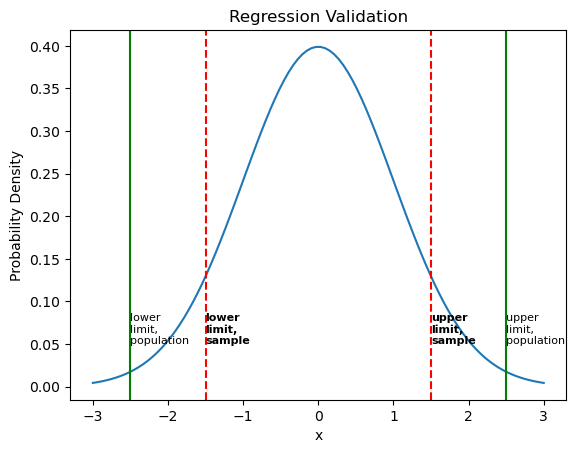

In [42]:
# Generate random numbers from a normal distribution
mu = 0  # mean
sigma = 1  # standard deviation
x = np.linspace(mu - 3*sigma, mu + 3*sigma, 100)
y = stats.norm.pdf(x, mu, sigma)

# Plot the normal distribution curve
plt.plot(x, y)
plt.title("Regression Validation")
plt.xlabel("x")
plt.ylabel("Probability Density")

plt.axvline(x=1.5, color='r', linestyle='--')
plt.axvline(x=-1.5, color='r', linestyle='--')
plt.axvline(x=2.5, color='g', linestyle='-')
plt.axvline(x=-2.5, color='g', linestyle='-')
plt.text(2.5,.05,'upper\nlimit,\npopulation',fontsize=8)
plt.text(1.5,.05,'upper\nlimit,\nsample',fontsize=8, fontweight ='bold')
plt.text(-2.5,.05,'lower\nlimit,\npopulation',fontsize=8)
plt.text(-1.5,.05,'lower\nlimit,\nsample',fontsize=8, fontweight ='bold')

#plt.savefig('Regression_Validation.png')
plt.show()

In [20]:
df = pd.read_csv("https://gitlab.com/adomakor412/sheardata/-/raw/main/preliminary_162x127.csv")
df

,1,2,3,4,5,6,7,8,9,10,...,120,121,122,123,124,125,126,127,Unnamed: 127,Unnamed: 128
0,NaN,Nr.,Lit.,Bez.,Einheiten E,Querschnittswerte - Section properties,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,b\nb,bw\nbw,h\nh,hf\nhf,"hh,top\nhh,top",...,f´c\nfc_prime,Vct_ACI,Vs_ACI,Vcal_sACI,Vmax_ACI,rat_smax,VACI_cal,gmod_ACI,NaN,NaN
2,NaN,Nr.,Lit.,Bez.,E,NaN,NaN,NaN,NaN,NaN,...,f´c\nfc_prime,Vct_ACI,Vs_ACI,Vcal_sACI,Vmax_ACI,rat_smax,VACI_cal,gmod_ACI,NaN,NaN
3,NaN,-,-,-,SI / A,mm,mm,mm,mm,mm,...,MPa,kN,kN,kN,kN,NaN,kN,NaN,NaN,NaN
4,Ahmad_1996_003_NNW-3,19,Ahmad; Xie; Yu (1996),NNW-3,A,"127,0","127,0","254,0",NaN,NaN,...,"39,1","26,82","41,06","67,88","134,08","0,506","67,88","1,286",NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
156,Rosenbusch_2003_002_1.4-1,817,Rosenbusch (2003),1.4/1,SI,"200,0","200,0","300,0",NaN,NaN,...,"45,5","58,26","49,37","107,63","291,28","0,369","107,63","1,585",NaN,NaN
157,Rosenbusch_2003_004_1.7-1,819,Rosenbusch (2003),1.7/1,SI,"200,0","200,0","300,0",NaN,NaN,...,"48,0","59,82","159,73","219,55","299,09","0,734","219,55","0,867",NaN,NaN
158,Kautsch_2010_001_A2,820,Kautsch (2010),A2,SI,"655,0","155,0","820,0","150,0","20,0",...,"28,4","98,76","291,68","390,44","493,81","0,791","390,44","1,683",NaN,NaN
159,Kautsch_2010_002_B2,821,Kautsch (2010),B2,SI,"655,0","155,0","820,0","150,0","20,0",...,"29,0","99,73","218,76","318,49","498,65","0,639","318,49","1,794",NaN,NaN


In [48]:
data = pd.read_csv("dataDropped_from_162by127_to_157rowsby84columns.csv", sep=";")
dfexp = data[data.columns[1:]]
dfexp.index = range(4, 161)
dfexp

,1,2,3,4,5,6,7,8,15,16,...,118,119,120,121,122,123,124,125,126,127
4,0.0,19.0,0.0,60.0,0.0,127.0,127.0,254.0,32258.0,127.0,...,41.5,37.5,39.1,26.82,41.06,67.88,134.08,0.506,67.88,1286.000
5,1.0,22.0,0.0,56.0,0.0,127.0,127.0,254.0,32258.0,127.0,...,100.2,96.2,97.8,41.32,41.06,82.39,206.62,0.399,82.39,1245.000
6,2.0,23.0,0.0,57.0,0.0,127.0,127.0,254.0,32258.0,127.0,...,91.8,87.8,89.4,39.51,53.38,92.89,197.53,0.470,92.89,1168.000
7,3.0,24.0,0.0,58.0,0.0,127.0,127.0,254.0,32258.0,127.0,...,105.3,101.3,102.9,42.38,64.05,106.44,211.92,0.502,106.44,1154.000
8,4.0,25.0,0.0,59.0,0.0,127.0,127.0,254.0,32258.0,127.0,...,100.8,96.8,98.4,41.45,41.06,82.51,207.26,0.398,82.51,1140.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
156,134.0,817.0,35.0,1.0,1.0,200.0,200.0,300.0,60000.0,150.0,...,47.9,43.9,45.5,58.26,49.37,107.63,291.28,0.369,107.63,1585.000
157,135.0,819.0,35.0,2.0,1.0,200.0,200.0,300.0,60000.0,150.0,...,50.4,46.4,48.0,59.82,159.73,219.55,299.09,0.734,219.55,0.867
158,31.0,820.0,16.0,25.0,1.0,655.0,155.0,820.0,207100.0,282.6,...,30.8,26.8,28.4,98.76,291.68,390.44,493.81,0.791,390.44,1683.000
159,32.0,821.0,16.0,27.0,1.0,655.0,155.0,820.0,207100.0,282.6,...,31.4,27.4,29.0,99.73,218.76,318.49,498.65,0.639,318.49,1794.000


In [43]:
dfexp2 = dfexp[dfexp['76'] < dfexp['126']]
dfexp2

,1,2,3,4,5,6,7,8,15,16,...,118,119,120,121,122,123,124,125,126,127
9,5.0,40.0,2.0,35.0,1.0,300.0,300.0,1000.0,300000.0,500.0,...,32.0,28.0,29.6,250.76,111.61,362.37,1253.79,0.289,362.37,0.734
10,6.0,42.0,8.0,36.0,1.0,300.0,300.0,1000.0,300000.0,500.0,...,38.0,34.0,35.6,275.00,111.61,386.61,1375.00,0.281,386.61,0.723
21,17.0,213.0,9.0,145.0,1.0,250.0,80.0,400.0,59200.0,200.0,...,34.1,30.1,31.7,28.42,105.40,133.82,142.09,0.942,133.82,0.916
137,132.0,660.0,34.0,23.0,0.0,457.2,457.2,870.0,397741.0,435.0,...,125.3,121.3,122.9,641.51,245.58,887.09,3207.54,0.277,887.09,0.845
157,135.0,819.0,35.0,2.0,1.0,200.0,200.0,300.0,60000.0,150.0,...,50.4,46.4,48.0,59.82,159.73,219.55,299.09,0.734,219.55,0.867
160,147.0,874.0,41.0,17.0,1.0,300.0,300.0,450.0,135000.0,225.0,...,20.6,16.6,18.2,85.03,243.79,328.82,425.14,0.773,328.82,0.985


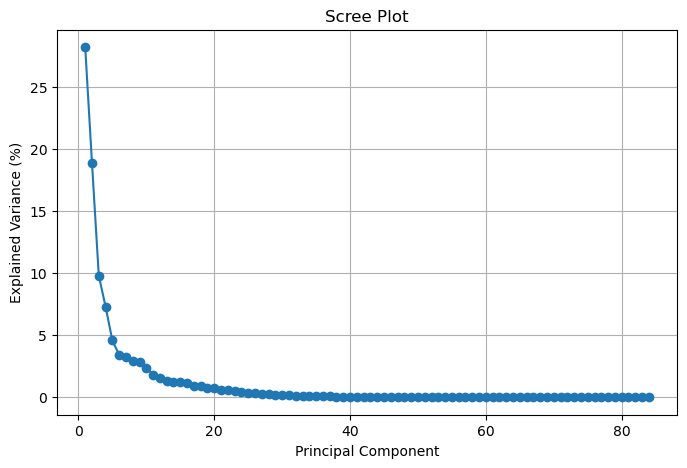

In [32]:
X = dfexp
#x = df_standard[df_standard.columns[:-1]]
X_scaled = StandardScaler().fit_transform(X)

pca = PCA()
pca.fit(X_scaled)

# n_component = 20
# random_state = 42
# pca = PCA(n_components = n_component, random_state = random_state)
variance_ratio = pca.explained_variance_ratio_

fig, ax = plt.subplots(figsize=(8,5))

ax.plot(
    range(1, len(variance_ratio)+1),
    variance_ratio * 100,
    '-o'
)

ax.set_xlabel("Principal Component")
ax.set_ylabel("Explained Variance (%)")
ax.set_title("Scree Plot")
ax.grid(True)

plt.show()

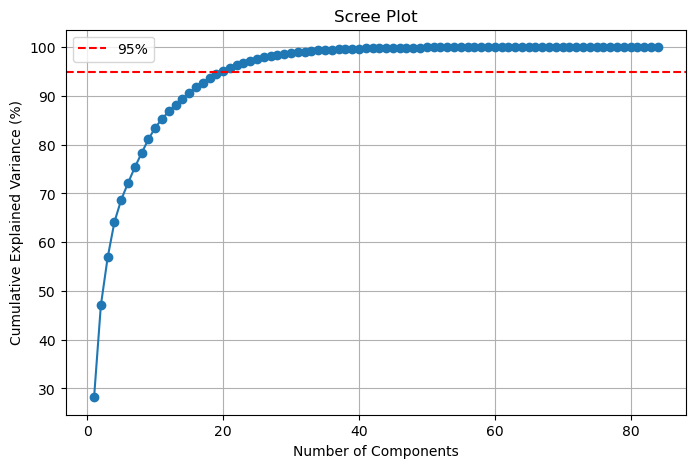

In [39]:
cum_var = np.cumsum(variance_ratio)

fig, ax = plt.subplots(figsize=(8,5))

ax.plot(
    range(1, len(cum_var)+1),
    cum_var * 100,
    '-o'
)

ax.axhline(95, color='red', linestyle='--', label='95%')

ax.set_xlabel("Number of Components")
ax.set_ylabel("Cumulative Explained Variance (%)")
ax.legend()
ax.grid(True)
ax.set_title("Scree Plot")
#plt.savefig("ScreePlot")
plt.show()


In [ ]:
components = range(1, len(eigenvalues) + 1)

fig, ax = plt.subplots(figsize=(8,5))

ax.plot(components, eigenvalues,
        marker='o',
        linewidth=2)

ax.set_xlabel("Principal Component")
ax.set_ylabel("Eigenvalue")
ax.set_title("Scree Plot")

ax.grid(True)

plt.show()
#plt.savefig("ScreePlot")

In [57]:
df_Target = dfexp[dfexp['76'] >= dfexp['126']]
listTargetIndex = list(df_Target.index)
listTargetIndex

[4,
 5,
 6,
 7,
 8,
 11,
 12,
 13,
 14,
 15,
 16,
 17,
 18,
 19,
 20,
 22,
 23,
 24,
 25,
 26,
 27,
 28,
 29,
 30,
 31,
 32,
 33,
 34,
 35,
 36,
 37,
 38,
 39,
 40,
 41,
 42,
 43,
 44,
 45,
 46,
 47,
 48,
 49,
 50,
 51,
 52,
 53,
 54,
 55,
 56,
 57,
 58,
 59,
 60,
 61,
 62,
 63,
 64,
 65,
 66,
 67,
 68,
 69,
 70,
 71,
 72,
 73,
 74,
 75,
 76,
 77,
 78,
 79,
 80,
 81,
 82,
 83,
 84,
 85,
 86,
 87,
 88,
 89,
 90,
 91,
 92,
 93,
 94,
 95,
 96,
 97,
 98,
 99,
 100,
 101,
 102,
 103,
 104,
 105,
 106,
 107,
 108,
 109,
 110,
 111,
 112,
 113,
 114,
 115,
 116,
 117,
 118,
 119,
 120,
 121,
 122,
 123,
 124,
 125,
 126,
 127,
 128,
 129,
 130,
 131,
 132,
 133,
 134,
 135,
 136,
 138,
 139,
 140,
 141,
 142,
 143,
 144,
 145,
 146,
 147,
 148,
 149,
 150,
 151,
 152,
 153,
 154,
 155,
 156,
 158,
 159]

In [58]:
len(listTargetIndex)

151

In [59]:
top20FeaturesNo = ["94","92","72","8","26","25","96","97","123","15","88","60","118","119","120","117","62","67","66","124"]
top20Features = ["z",#94
                 "z_test",#92
                 "V_g",#72
                 "h",#8
                 "d",#26
                 "d_s",#25
                 "M_u,flex",#96
                 "V_u,flex",#97
                 "V_cal_s,ACI",#123
                 "A_c",#15
                 "K_c",#88
                 "f_1c",#60
                 "f_cm,cyl",#118
                 "f_ck",#119
                 "f'c",#120
                 "f_1ck",#117
                 "f_cwu",#62
                 "B_ct,cal",#67
                 "f_1ct,m,cal",#66
                 "Vmax_ACI" #124
                ]

# For loop to iterate over curve: z v. Vu by f'c

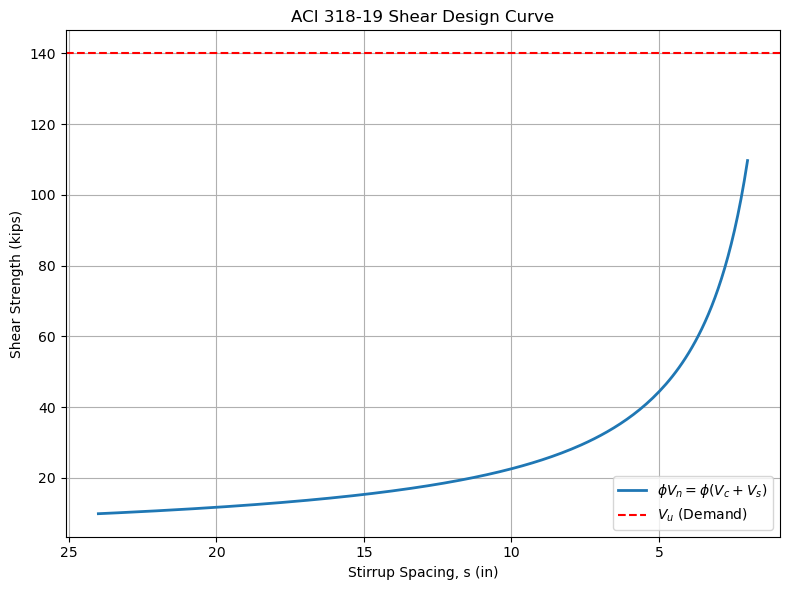

In [60]:
# -------------------------------
# Beam & Material Properties
# -------------------------------

fc = 4.0          # Concrete strength f'c (ksi)
fy = 60.0         # Steel yield strength (ksi)
bw = 12.0         # Web width (in)
d = 22.0          # Effective depth (in)
phi = 0.75        # Strength reduction factor
lambda_c = 1.0    # Normal weight concrete

# Stirrup properties
Av = 2 * 0.11     # Area of shear reinforcement (in^2)
                  # Example: two-leg #3 stirrup → 2 × 0.11

# -------------------------------
# Applied Shear Demand
# -------------------------------

Vu = 140.0        # Factored shear demand (kips)

# -------------------------------
# ACI Shear Calculations
# -------------------------------

# Concrete shear strength (kips)
Vc = 2 * lambda_c * np.sqrt(fc) * bw * d / 1000

# Stirrup spacing range (in)
s = np.linspace(2, 24, 200)

# Steel shear contribution (kips)
Vs = Av * fy * d / s

# Nominal & design shear strength
Vn = Vc + Vs
phiVn = phi * Vn

# -------------------------------
# Plot
# -------------------------------

plt.figure(figsize=(8, 6))
plt.plot(s, phiVn, label=r'$\phi V_n = \phi (V_c + V_s)$', linewidth=2)
plt.axhline(Vu, linestyle='--', color='red', label=r'$V_u$ (Demand)')

plt.gca().invert_xaxis()  # Conventional: tighter spacing to the left
plt.xlabel('Stirrup Spacing, s (in)')
plt.ylabel('Shear Strength (kips)')
plt.title('ACI 318-19 Shear Design Curve')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

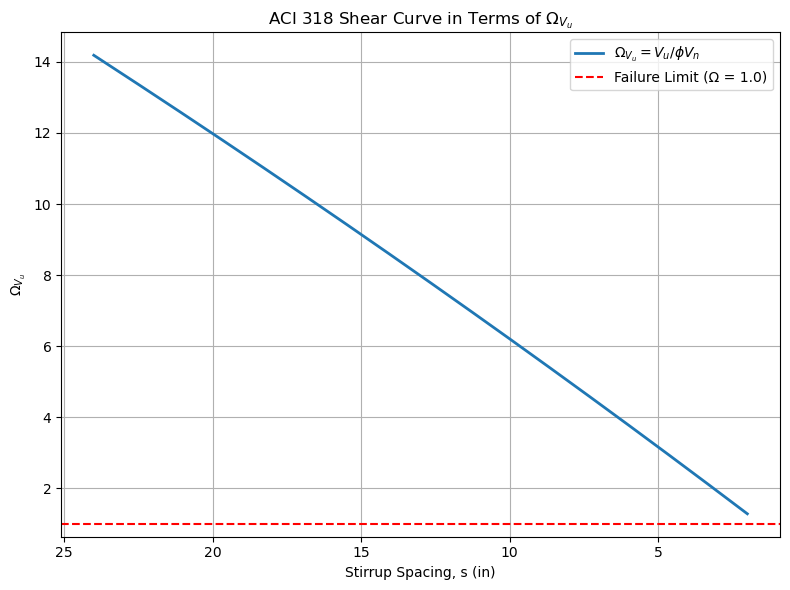

In [61]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------
# Beam & Material Properties
# -------------------------------

fc = 4.0          # Concrete strength f'c (ksi)
fy = 60.0         # Steel yield strength (ksi)
bw = 12.0         # Web width (in)
d = 22.0          # Effective depth (in)
phi = 0.75        # Strength reduction factor
lambda_c = 1.0    # Normal-weight concrete

# Stirrup properties
Av = 2 * 0.11     # Two-leg #3 stirrup (in^2)

# -------------------------------
# Shear Demand
# -------------------------------

Vu = 140.0        # Factored shear demand (kips)

# -------------------------------
# ACI Shear Strength
# -------------------------------

# Concrete contribution (kips)
Vc = 2 * lambda_c * np.sqrt(fc) * bw * d / 1000

# Stirrup spacing range (in)
s = np.linspace(2, 24, 300)

# Steel contribution (kips)
Vs = Av * fy * d / s

# Design shear strength
phiVn = phi * (Vc + Vs)

# -------------------------------
# Omega_vu Calculation
# -------------------------------

omega_vu = Vu / phiVn

# -------------------------------
# Plot
# -------------------------------

plt.figure(figsize=(8, 6))
plt.plot(s, omega_vu, linewidth=2, label=r'$\Omega_{V_u} = V_u / \phi V_n$')
plt.axhline(1.0, linestyle='--', color='red', label='Failure Limit (Ω = 1.0)')

plt.gca().invert_xaxis()
plt.xlabel('Stirrup Spacing, s (in)')
plt.ylabel(r'$\Omega_{V_u}$')
plt.title('ACI 318 Shear Curve in Terms of $\Omega_{V_u}$')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [62]:
fpc = dfexp['120'].unique()
fpc

array([ 39.1,  97.8,  89.4, 102.9,  98.4,  29.6,  35.6,  42.1,  40.9,
        24.8,  23.1,  24.3,  23.4,  21.7,  27.2,  84.6,  27.8,  31.7,
        14.4,  31.6,  22.5,  28.6,  17.1,  67.6,  26.6,  34. ,  53.5,
        59.2,  67.8,  62.9,  82.1,  84.2,  70. ,  69.8,  37.7,  35.3,
        34.8,  39. ,  28. ,  39.4,  13.3,  33. ,  40.3,  21.4,  21.8,
        15.2,  14.6,  23.8,  20. ,  19. ,  14.1,  22.6,  44.6,  47.6,
        57.6,  23.3,  24.2,  38.3,  31. ,  28.1,  58.6,  79.6,  72.6,
        70.6,  40.6,  45. ,  25.3,  18.9,  32.9,  29.3,  49.5,  11.2,
        25.7,  27.6,  28.3,  27.5,  43.1,  31.9,  22.1,  19.7,  58.2,
       122.9,  77.7,  71.8,  73.3,  49.6,  31.8,  85. ,  85.9,  86.9,
        86.8,  16.9,  33.6,  64.6,  45.5,  48. ,  28.4,  29. ,  18.2])

In [63]:
fpc.sort()
fpc

array([ 11.2,  13.3,  14.1,  14.4,  14.6,  15.2,  16.9,  17.1,  18.2,
        18.9,  19. ,  19.7,  20. ,  21.4,  21.7,  21.8,  22.1,  22.5,
        22.6,  23.1,  23.3,  23.4,  23.8,  24.2,  24.3,  24.8,  25.3,
        25.7,  26.6,  27.2,  27.5,  27.6,  27.8,  28. ,  28.1,  28.3,
        28.4,  28.6,  29. ,  29.3,  29.6,  31. ,  31.6,  31.7,  31.8,
        31.9,  32.9,  33. ,  33.6,  34. ,  34.8,  35.3,  35.6,  37.7,
        38.3,  39. ,  39.1,  39.4,  40.3,  40.6,  40.9,  42.1,  43.1,
        44.6,  45. ,  45.5,  47.6,  48. ,  49.5,  49.6,  53.5,  57.6,
        58.2,  58.6,  59.2,  62.9,  64.6,  67.6,  67.8,  69.8,  70. ,
        70.6,  71.8,  72.6,  73.3,  77.7,  79.6,  82.1,  84.2,  84.6,
        85. ,  85.9,  86.8,  86.9,  89.4,  97.8,  98.4, 102.9, 122.9])

In [64]:
len(fpc)

99

In [65]:
for f in [60,118,119,120,117,62,67,66]:
    f_dict = {}
    
    k = str(f)
    print(top20Features[top20FeaturesNo.index(k)])
    
    k_list = dfexp[k].unique()
    print(f'{f}, count:{len(k_list)}')

    k_list.sort()
    print(k_list)
    
    for v in dfexp[k]:
        f_dict[v] = f_dict.get(v, 0) + 1

f_1c
60, count:105
[ 12.9   14.94  15.7   15.99  16.19  16.68  18.29  18.53  18.56  19.57
  20.25  20.31  21.03  21.29  21.3   22.56  22.87  22.93  23.01  23.23
  23.63  23.67  23.75  24.18  24.42  24.49  24.92  25.27  25.34  25.88
  26.33  26.7   27.55  28.11  28.41  28.5   28.69  28.89  28.98  29.18
  29.3   29.43  29.83  30.08  30.4   31.69  32.3   32.37  32.53  32.59
  33.53  33.68  34.2   34.59  35.31  35.77  36.1   38.1   38.13  38.66
  39.31  39.46  39.7   40.56  40.85  41.14  42.25  43.23  44.65  45.08
  45.5   47.5   47.85  49.28  49.4   53.07  57.    57.57  57.95  58.51
  62.01  63.65  66.5   66.7   68.63  68.79  68.82  69.35  70.49  71.25
  71.92  76.1   77.9   80.32  82.25  82.65  83.    83.9   84.7   84.8
  87.18  95.17  95.74  99.99 119.04]
f_cm,cyl
118, count:99
[ 13.6  15.7  16.5  16.8  17.   17.6  19.3  19.5  20.6  21.3  21.4  22.1
  22.4  23.8  24.1  24.2  24.5  24.9  25.   25.5  25.7  25.8  26.2  26.6
  26.7  27.2  27.7  28.1  29.   29.6  29.9  30.   30.2  30.4  30.5

In [66]:
#fpc_dict = {k,c for v in dfexp["120"]

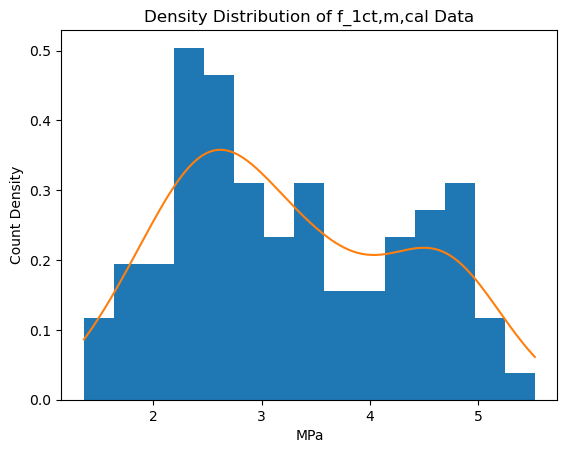

In [68]:
data = np.array([

1.36, 1.56, 1.63, 1.65, 1.67, 1.72, 1.86, 1.88, 1.97, 2.02, 2.03, 2.08,

2.11, 2.21, 2.23, 2.24, 2.26, 2.29, 2.30, 2.33, 2.35, 2.36, 2.39, 2.41,

2.42, 2.46, 2.49, 2.52, 2.58, 2.62, 2.64, 2.65, 2.66, 2.68, 2.70, 2.71,

2.72, 2.74, 2.76, 2.78, 2.87, 2.92, 2.93, 2.94, 3.00, 3.01, 3.04, 3.07,

3.12, 3.15, 3.17, 3.30, 3.33, 3.38, 3.39, 3.40, 3.45, 3.47, 3.49, 3.56,

3.62, 3.71, 3.73, 3.76, 3.88, 3.90, 3.98, 3.99, 4.16, 4.27, 4.28, 4.29,

4.31, 4.40, 4.44, 4.51, 4.56, 4.57, 4.60, 4.62, 4.63, 4.73, 4.76, 4.82,

4.86, 4.87, 4.89, 4.91, 4.96, 5.11, 5.12, 5.20, 5.52

])

# KDE

kde = stats.gaussian_kde(data)

x_vals = np.linspace(min(data), max(data), 200)

y_vals = kde(x_vals)

# Plot

plt.figure()

plt.hist(data, bins=15, density=True)

plt.plot(x_vals, y_vals)

plt.xlabel("MPa")

plt.ylabel("Count Density")

plt.title("Density Distribution of f_1ct,m,cal Data")
#plt.savefig("Thesis_output_figures/f__1ct_m_cal density")
plt.show()


In [69]:
print("Mean:", np.mean(data))
print("Median:", np.median(data))
print("Std Dev:", np.std(data))

Mean: 3.2579569892473113
Median: 3.04
Std Dev: 1.049108745288303


# f_1ct, m, cal Data, #66

In [50]:
y_V_ACI_2_3 = [] #123
y_V_max_2_3 = []#124
y_V_ACI_cal_2_3 = []#126

x_Vu_2_3 = []#97
x_z_2_3 = []#94

y_V_ACI_4_5 = [] #123
y_V_max_4_5 = []#124
y_V_ACI_cal_4_5 = []#126

x_Vu_4_5 = []#97
x_z_4_5 = []#94

for i, r in dfexp.iterrows():
    f_cal = r['66']

    V_ACI = r['123']
    V_max = r['124']
    V_ACI_cal = r['126']
    Vu = r['97']
    z = r['94']
    if 2<=float(f_cal)<=3:
        y_V_ACI_2_3.append(float(r['123']))
        y_V_max_2_3.append(float(r['124']))
        y_V_ACI_cal_2_3.append(float(r['126']))
        x_Vu_2_3.append(float(r['97']))
        x_z_2_3.append(float(r['94']))
    elif 4<=float(f_cal)<=5:
        y_V_ACI_4_5.append(float(r['123']))
        y_V_max_4_5.append(float(r['124']))
        y_V_ACI_cal_4_5.append(float(r['126']))
        x_Vu_4_5.append(float(r['97']))
        x_z_4_5.append(float(r['94']))
    else:
        None
        
        
    

In [86]:
print(len(x_z_2_3))
print(len(y_V_ACI_2_3))
print(len(y_V_max_2_3))
print(len(y_V_ACI_cal_2_3))
print(len(x_Vu_2_3))

52
52
52
52
52


In [112]:
x_z_2_3

[877.0,
 265.0,
 527.0,
 794.0,
 1055.0,
 354.0,
 371.0,
 195.0,
 345.0,
 257.0,
 267.0,
 281.0,
 327.0,
 318.0,
 379.0,
 379.0,
 390.0,
 398.0,
 257.0,
 257.0,
 257.0,
 762.0,
 349.0,
 349.0,
 345.0,
 345.0,
 345.0,
 345.0,
 823.0,
 823.0,
 490.0,
 491.0,
 273.0,
 271.0,
 271.0,
 219.0,
 209.0,
 225.0,
 223.0,
 219.0,
 211.0,
 221.0,
 222.0,
 234.0,
 238.0,
 238.0,
 377.0,
 480.0,
 275.0,
 264.0,
 675.0,
 676.0]

In [87]:
myZip = zip(x_z_2_3,y_V_ACI_2_3)

In [88]:
myList = list(myZip)

In [111]:
myList

[(195.0, 86.25),
 (209.0, 71.36),
 (211.0, 72.16),
 (219.0, 117.99),
 (219.0, 118.24),
 (221.0, 119.42),
 (222.0, 119.85),
 (223.0, 78.16),
 (225.0, 80.25),
 (234.0, 273.88),
 (238.0, 260.08),
 (238.0, 404.53),
 (257.0, 59.93),
 (257.0, 71.44),
 (257.0, 82.95),
 (257.0, 340.18),
 (264.0, 65.57),
 (265.0, 106.41),
 (267.0, 122.43),
 (271.0, 83.33),
 (271.0, 83.33),
 (273.0, 84.76),
 (275.0, 69.95),
 (281.0, 121.02),
 (318.0, 142.85),
 (327.0, 83.73),
 (345.0, 133.82),
 (345.0, 182.83),
 (345.0, 182.83),
 (345.0, 266.51),
 (345.0, 364.9),
 (349.0, 131.31),
 (349.0, 188.07),
 (354.0, 156.61),
 (371.0, 107.81),
 (377.0, 541.53),
 (379.0, 178.39),
 (379.0, 178.39),
 (390.0, 136.65),
 (398.0, 148.77),
 (480.0, 643.83),
 (490.0, 280.63),
 (491.0, 272.47),
 (527.0, 208.45),
 (675.0, 390.44),
 (676.0, 318.49),
 (762.0, 1084.63),
 (794.0, 317.17),
 (823.0, 542.66),
 (823.0, 542.66),
 (877.0, 362.37),
 (1055.0, 418.51)]

In [108]:
#list.sort?

In [109]:
plot_pair(myList)

[(195.0, 86.25),
 (209.0, 71.36),
 (211.0, 72.16),
 (219.0, 117.99),
 (219.0, 118.24),
 (221.0, 119.42),
 (222.0, 119.85),
 (223.0, 78.16),
 (225.0, 80.25),
 (234.0, 273.88),
 (238.0, 260.08),
 (238.0, 404.53),
 (257.0, 59.93),
 (257.0, 71.44),
 (257.0, 82.95),
 (257.0, 340.18),
 (264.0, 65.57),
 (265.0, 106.41),
 (267.0, 122.43),
 (271.0, 83.33),
 (271.0, 83.33),
 (273.0, 84.76),
 (275.0, 69.95),
 (281.0, 121.02),
 (318.0, 142.85),
 (327.0, 83.73),
 (345.0, 133.82),
 (345.0, 182.83),
 (345.0, 182.83),
 (345.0, 266.51),
 (345.0, 364.9),
 (349.0, 131.31),
 (349.0, 188.07),
 (354.0, 156.61),
 (371.0, 107.81),
 (377.0, 541.53),
 (379.0, 178.39),
 (379.0, 178.39),
 (390.0, 136.65),
 (398.0, 148.77),
 (480.0, 643.83),
 (490.0, 280.63),
 (491.0, 272.47),
 (527.0, 208.45),
 (675.0, 390.44),
 (676.0, 318.49),
 (762.0, 1084.63),
 (794.0, 317.17),
 (823.0, 542.66),
 (823.0, 542.66),
 (877.0, 362.37),
 (1055.0, 418.51)]

In [122]:
def plot_pair(listOfPairs):
    sortedList = list.sort(listOfPairs, key = lambda x:(x[0],x[1]), reverse = False) #function
    #return listOfPairs
    '''return a pair of list'''
    x, y = [], []
    #print("type: ", type(sortedList))
    for p in listOfPairs:
        x.append(p[0])
        y.append(p[1])
    return x,y

In [123]:
print(plot_pair(list(zip(x_z_2_3,y_V_ACI_2_3))))

([195.0, 209.0, 211.0, 219.0, 219.0, 221.0, 222.0, 223.0, 225.0, 234.0, 238.0, 238.0, 257.0, 257.0, 257.0, 257.0, 264.0, 265.0, 267.0, 271.0, 271.0, 273.0, 275.0, 281.0, 318.0, 327.0, 345.0, 345.0, 345.0, 345.0, 345.0, 349.0, 349.0, 354.0, 371.0, 377.0, 379.0, 379.0, 390.0, 398.0, 480.0, 490.0, 491.0, 527.0, 675.0, 676.0, 762.0, 794.0, 823.0, 823.0, 877.0, 1055.0], [86.25, 71.36, 72.16, 117.99, 118.24, 119.42, 119.85, 78.16, 80.25, 273.88, 260.08, 404.53, 59.93, 71.44, 82.95, 340.18, 65.57, 106.41, 122.43, 83.33, 83.33, 84.76, 69.95, 121.02, 142.85, 83.73, 133.82, 182.83, 182.83, 266.51, 364.9, 131.31, 188.07, 156.61, 107.81, 541.53, 178.39, 178.39, 136.65, 148.77, 643.83, 280.63, 272.47, 208.45, 390.44, 318.49, 1084.63, 317.17, 542.66, 542.66, 362.37, 418.51])


/var/folders/6v/t0sc3vc144110dlllnnd3gz80000gn/T/ipykernel_20187/2463189584.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


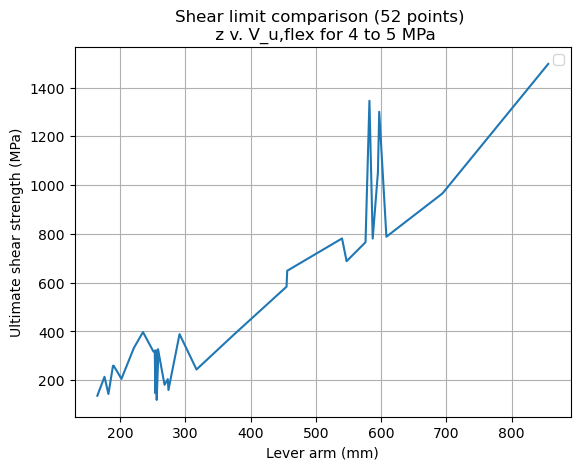

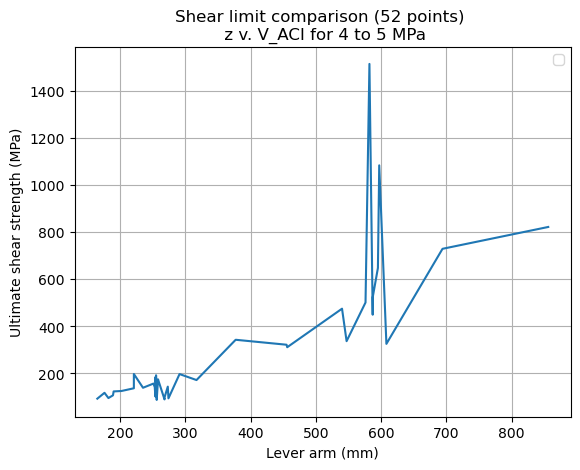

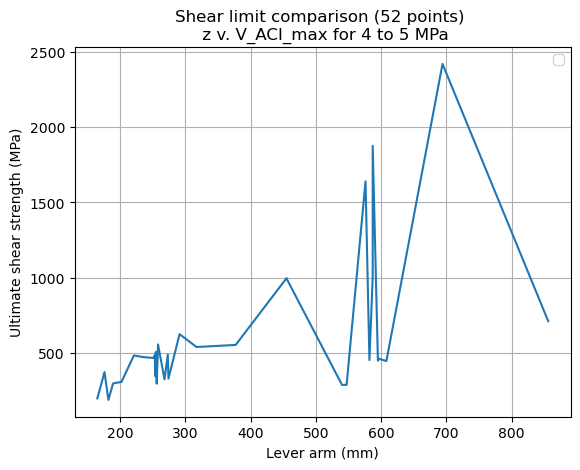

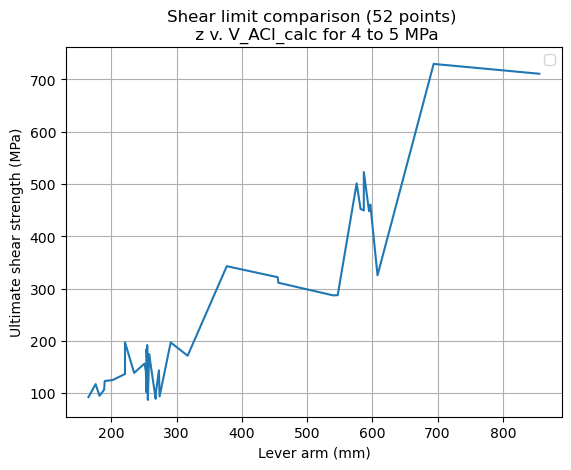

In [129]:
plt.figure()
#plt.hist(data, bins=15, density=True)

for y in [(x_Vu_4_5,"V_u,flex"), (y_V_ACI_4_5,"V_ACI"), (y_V_max_4_5,"V_ACI_max"),(y_V_ACI_cal_4_5,"V_ACI_calc")]:
    plt.plot(*plot_pair(list(zip(x_z_4_5,y[0]))))
    plt.xlabel("Lever arm (mm)")
    plt.ylabel("Ultimate shear strength (MPa)")
    plt.legend()
    plt.grid(True)
    plt.title(f"Shear limit comparison (52 points) \n z v. {y[1]} for 4 to 5 MPa")
    plt.savefig(f"Thesis_output_figures/ShearLimitComparison_{y[1]}_4to5MPa.png")
    plt.show()

/var/folders/6v/t0sc3vc144110dlllnnd3gz80000gn/T/ipykernel_20187/3106976906.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


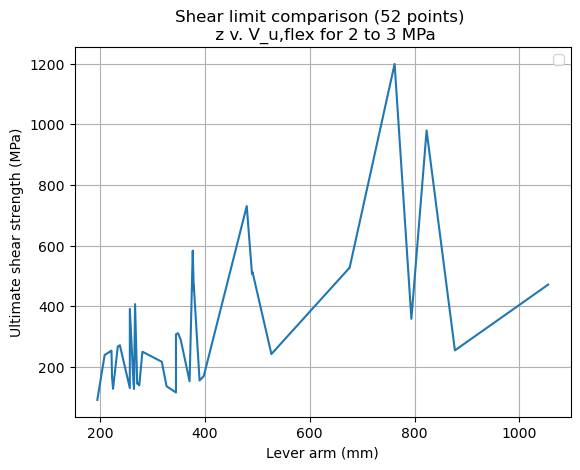

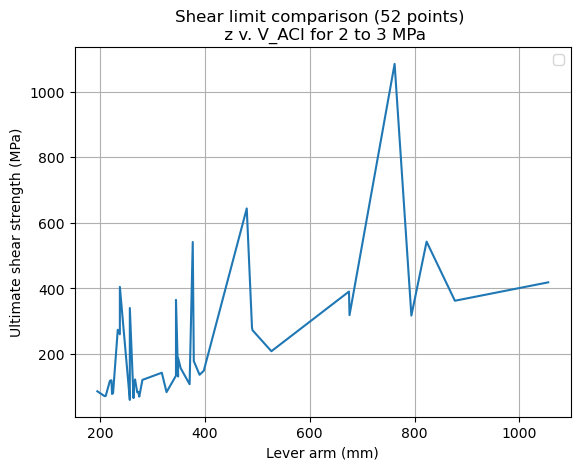

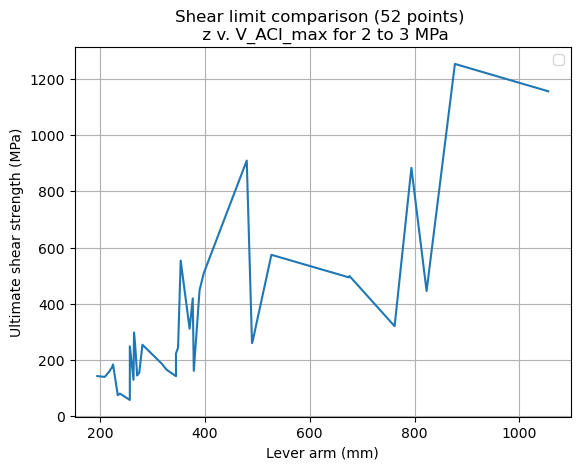

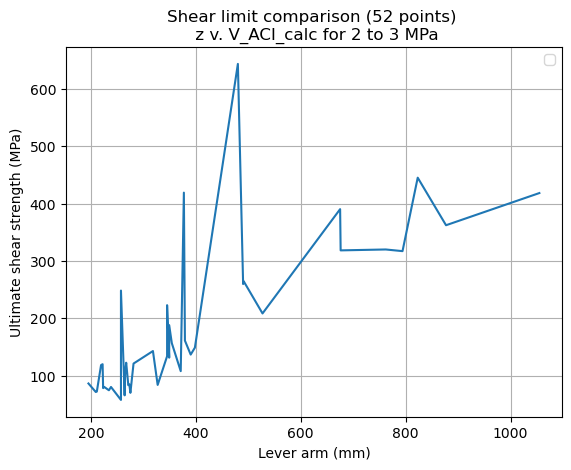

In [128]:
plt.figure()
#plt.hist(data, bins=15, density=True)

for y in [(x_Vu_2_3,"V_u,flex"), (y_V_ACI_2_3,"V_ACI"), (y_V_max_2_3,"V_ACI_max"),(y_V_ACI_cal_2_3,"V_ACI_calc")]:
    plt.plot(*plot_pair(list(zip(x_z_2_3,y[0]))))
    plt.xlabel("Lever arm (mm)")
    plt.ylabel("Ultimate shear strength (MPa)")
    plt.legend()
    plt.grid(True)
    plt.title(f"Shear limit comparison (52 points) \n z v. {y[1]} for 2 to 3 MPa")
    plt.savefig(f"Thesis_output_figures/ShearLimitComparison_{y[1]}_2to3MPa.png")
    plt.show()

/var/folders/6v/t0sc3vc144110dlllnnd3gz80000gn/T/ipykernel_20187/1865369823.py:15: RuntimeWarning: overflow encountered in exp
  return a * np.exp(b * x)
/Users/miner/anaconda3/envs/myenv/lib/python3.11/site-packages/scipy/optimize/_minpack_py.py:1024: RuntimeWarning: overflow encountered in square
  cost = np.sum(infodict['fvec'] ** 2)
/var/folders/6v/t0sc3vc144110dlllnnd3gz80000gn/T/ipykernel_20187/1865369823.py:18: OptimizeWarning: Covariance of the parameters could not be estimated
  params, _ = curve_fit(expo, x, y)


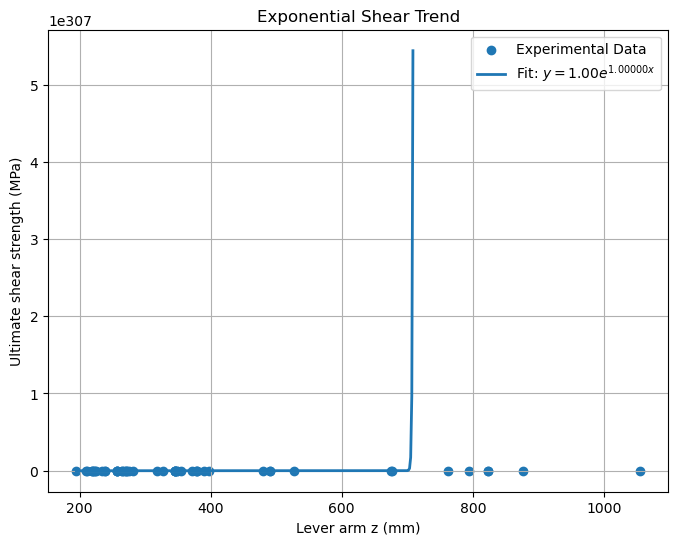

In [131]:

x = np.array(x_z_2_3)
y = np.array(y_V_ACI_cal_2_3)

# Sort by x
idx = np.argsort(x)
x = x[idx]
y = y[idx]

# -------------------------
# Exponential model
# y = a * exp(bx)
# -------------------------

def expo(x, a, b):
    return a * np.exp(b * x)

# Fit parameters
params, _ = curve_fit(expo, x, y)

a, b = params

# Smooth curve
x_fit = np.linspace(x.min(), x.max(), 500)
y_fit = expo(x_fit, a, b)

# -------------------------
# Plot
# -------------------------

plt.figure(figsize=(8,6))

# Original data
plt.scatter(x, y, label='Experimental Data')

# Exponential trend
plt.plot(x_fit, y_fit,
         linewidth=2,
         label=fr'Fit: $y={a:.2f}e^{{{b:.5f}x}}$')

plt.xlabel("Lever arm z (mm)")
plt.ylabel("Ultimate shear strength (MPa)")
plt.title("Exponential Shear Trend")
plt.grid(True)
plt.legend()

plt.show()

/var/folders/6v/t0sc3vc144110dlllnnd3gz80000gn/T/ipykernel_20187/3853608237.py:15: RuntimeWarning: overflow encountered in exp
  return a * np.exp(b * x)
/var/folders/6v/t0sc3vc144110dlllnnd3gz80000gn/T/ipykernel_20187/3853608237.py:18: OptimizeWarning: Covariance of the parameters could not be estimated
  params, _ = curve_fit(expo, x, y)
/Users/miner/anaconda3/envs/myenv/lib/python3.11/site-packages/matplotlib/ticker.py:2178: RuntimeWarning: overflow encountered in multiply
  steps = self._extended_steps * scale


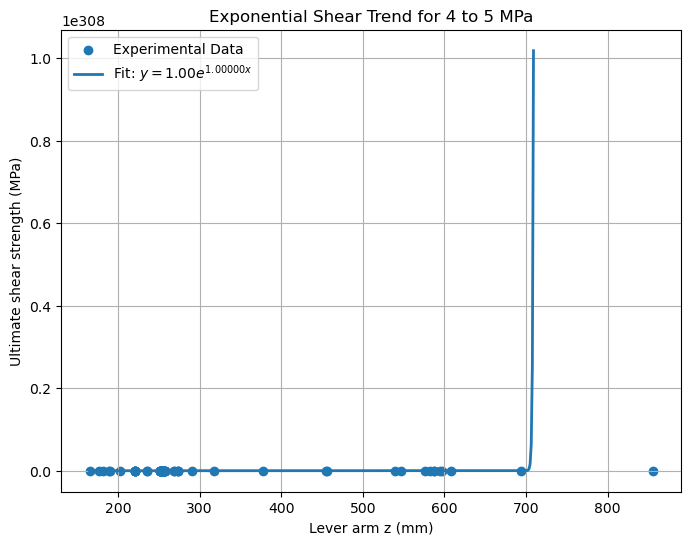

In [132]:

x = np.array(x_z_4_5)
y = np.array(y_V_ACI_cal_4_5)

# Sort by x
idx = np.argsort(x)
x = x[idx]
y = y[idx]

# -------------------------
# Exponential model
# y = a * exp(bx)
# -------------------------

def expo(x, a, b):
    return a * np.exp(b * x)

# Fit parameters
params, _ = curve_fit(expo, x, y)

a, b = params

# Smooth curve
x_fit = np.linspace(x.min(), x.max(), 500)
y_fit = expo(x_fit, a, b)

# -------------------------
# Plot
# -------------------------

plt.figure(figsize=(8,6))

# Original data
plt.scatter(x, y, label='Experimental Data')

# Exponential trend
plt.plot(x_fit, y_fit,
         linewidth=2,
         label=fr'Fit: $y={a:.2f}e^{{{b:.5f}x}}$')

plt.xlabel("Lever arm z (mm)")
plt.ylabel("Ultimate shear strength (MPa)")
plt.title("Exponential Shear Trend for 4 to 5 MPa")
plt.grid(True)
plt.legend()

plt.show()

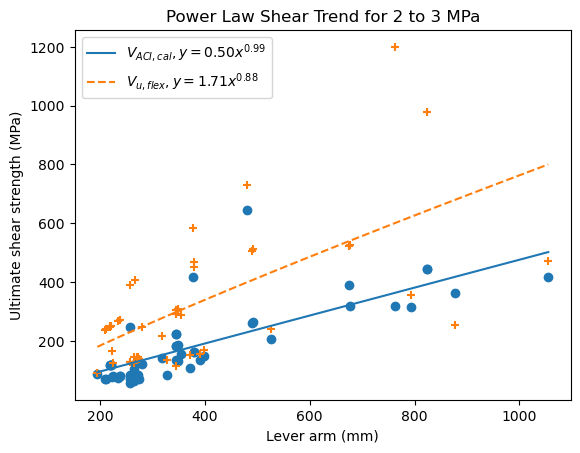

In [51]:
def power(x, a, b):
    return a * x**b
    
x = np.array(x_z_2_3)
y = np.array(y_V_ACI_cal_2_3)
z = np.array(x_Vu_2_3)
# Sort by x
idx = np.argsort(x)
x = x[idx]
y = y[idx]
z = z[idx]

params, _ = curve_fit(power, x, y)

a, b = params

x_fit = np.linspace(x.min(), x.max(), 500)
y_fit = power(x_fit, a, b)
plt.xlabel("Lever arm (mm)")
plt.ylabel("Ultimate shear strength (MPa)")
plt.scatter(x, y)
plt.plot(x_fit, y_fit, label=fr'$V_{{ACI,cal}}, y={a:.2f}x^{{{b:.2f}}}$')
plt.title("Power Law Shear Trend for 2 to 3 MPa")
plt.savefig(f"Thesis_output_figures/PowerLawShearTrendfor2to3MPa.png")
params, _ = curve_fit(power, x, z)
a, b = params
x_fit = np.linspace(x.min(), x.max(), 500)
z_fit = power(x_fit, a, b)
plt.scatter(x, z, marker='+')
plt.plot(x_fit, z_fit, '--',label=fr'$V_{{u,flex}}, y={a:.2f}x^{{{b:.2f}}}$')
plt.legend()
plt.show()

In [169]:
plt.plot?

Signature:
plt.plot(
    *args: 'float | ArrayLike | str',
    scalex: 'bool' = True,
    scaley: 'bool' = True,
    data=None,
    **kwargs,
) -> 'list[Line2D]'
Docstring:
Plot y versus x as lines and/or markers.

Call signatures::

    plot([x], y, [fmt], *, data=None, **kwargs)
    plot([x], y, [fmt], [x2], y2, [fmt2], ..., **kwargs)

The coordinates of the points or line nodes are given by *x*, *y*.

The optional parameter *fmt* is a convenient way for defining basic
formatting like color, marker and linestyle. It's a shortcut string
notation described in the *Notes* section below.

>>> plot(x, y)        # plot x and y using default line style and color
>>> plot(x, y, 'bo')  # plot x and y using blue circle markers
>>> plot(y)           # plot y using x as index array 0..N-1
>>> plot(y, 'r+')     # ditto, but with red plusses

You can use `.Line2D` properties as keyword arguments for more
control on the appearance. Line properties and *fmt* can be mixed.
The following two calls yie

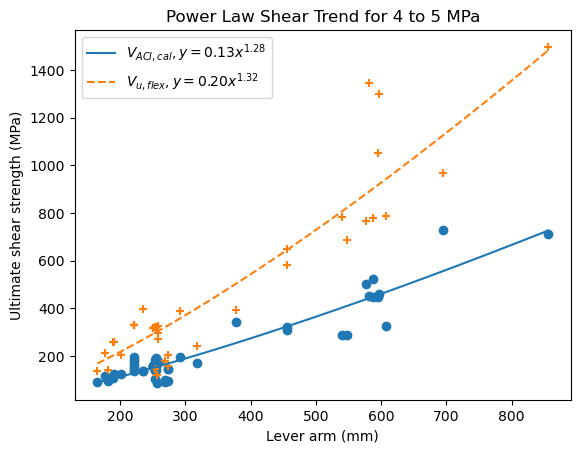

In [171]:
def power(x, a, b):
    return a * x**b
    
x = np.array(x_z_4_5)
y = np.array(y_V_ACI_cal_4_5)
z = np.array(x_Vu_4_5)

# Sort by x
idx = np.argsort(x)
x = x[idx]
y = y[idx]
z = z[idx]

params, _ = curve_fit(power, x, y)

a, b = params

x_fit = np.linspace(x.min(), x.max(), 500)
y_fit = power(x_fit, a, b)

plt.scatter(x, y)
plt.plot(x_fit, y_fit, label=fr'$V_{{ACI,cal}},y={a:.2f}x^{{{b:.2f}}}$')
plt.xlabel("Lever arm (mm)")
plt.ylabel("Ultimate shear strength (MPa)")
plt.title("Power Law Shear Trend for 4 to 5 MPa")
plt.savefig(f"Thesis_output_figures/PowerLawShearTrendfor4to5MPa.png")

params, _ = curve_fit(power, x, z)
a, b = params
x_fit = np.linspace(x.min(), x.max(), 500)
z_fit = power(x_fit, a, b)
plt.scatter(x, z, marker='+')
plt.plot(x_fit, z_fit, '--',label=fr'$V_{{u,flex}}, y={a:.2f}x^{{{b:.2f}}}$')
plt.legend()
plt.show()

In [45]:
y_V_ACI_2_3_prime = [] #123
y_V_max_2_3_prime = []#124
y_V_ACI_cal_2_3_prime = []#126

x_Vu_2_3_prime = []#97
x_z_2_3_prime = []#94

y_V_ACI_4_5_prime = [] #123
y_V_max_4_5_prime = []#124
y_V_ACI_cal_4_5_prime = []#126

x_Vu_4_5_prime = []#97
x_z_4_5_prime = []#94

for i, r in dfexp2.iterrows():
    f_cal = r['66']

    V_ACI = r['123']
    V_max = r['124']
    V_ACI_cal = r['126']
    Vu = r['97']
    z = r['94']
    if 2<=float(f_cal)<=3:
        y_V_ACI_2_3_prime.append(float(r['123']))
        y_V_max_2_3_prime.append(float(r['124']))
        y_V_ACI_cal_2_3_prime.append(float(r['126']))
        x_Vu_2_3_prime.append(float(r['97']))
        x_z_2_3_prime.append(float(r['94']))
    elif 4<=float(f_cal)<=5:
        y_V_ACI_4_5_prime.append(float(r['123']))
        y_V_max_4_5_prime.append(float(r['124']))
        y_V_ACI_cal_4_5_prime.append(float(r['126']))
        x_Vu_4_5_prime.append(float(r['97']))
        x_z_4_5_prime.append(float(r['94']))
    else:
        None

/var/folders/6v/t0sc3vc144110dlllnnd3gz80000gn/T/ipykernel_32393/2929945794.py:13: OptimizeWarning: Covariance of the parameters could not be estimated
  params, _ = curve_fit(power, x, y)
/var/folders/6v/t0sc3vc144110dlllnnd3gz80000gn/T/ipykernel_32393/2929945794.py:25: OptimizeWarning: Covariance of the parameters could not be estimated
  params, _ = curve_fit(power, x, z)


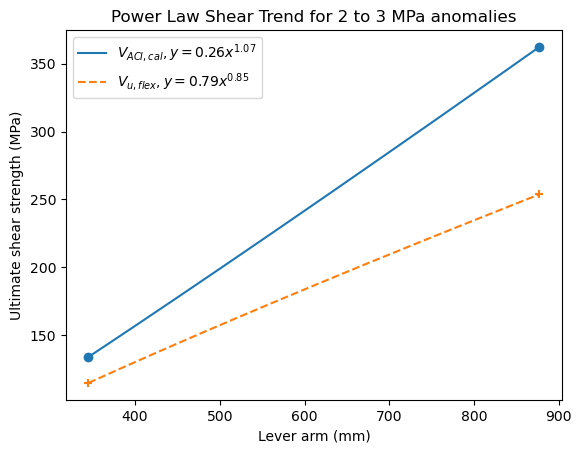

<Figure size 640x480 with 0 Axes>

In [54]:
def power(x, a, b):
    return a * x**b
    
x = np.array(x_z_2_3_prime)
y = np.array(y_V_ACI_cal_2_3_prime)
z = np.array(x_Vu_2_3_prime)
# Sort by x
idx = np.argsort(x)
x = x[idx]
y = y[idx]
z = z[idx]

params, _ = curve_fit(power, x, y)

a, b = params

x_fit = np.linspace(x.min(), x.max(), 500)
y_fit = power(x_fit, a, b)
plt.xlabel("Lever arm (mm)")
plt.ylabel("Ultimate shear strength (MPa)")
plt.scatter(x, y)
plt.plot(x_fit, y_fit, label=fr'$V_{{ACI,cal}}, y={a:.2f}x^{{{b:.2f}}}$')
plt.title("Power Law Shear Trend for 2 to 3 MPa anomalies")

params, _ = curve_fit(power, x, z)
a, b = params
x_fit = np.linspace(x.min(), x.max(), 500)
z_fit = power(x_fit, a, b)
plt.scatter(x, z, marker='+')
plt.plot(x_fit, z_fit, '--',label=fr'$V_{{u,flex}}, y={a:.2f}x^{{{b:.2f}}}$')
plt.legend()
plt.show()
plt.savefig(f"Thesis_output_figures/PowerLawShearTrendfor2to3MPa_anomalies.png")
#plt.savefig(f"Thesis_output_figures/PowerLawShearTrendfor2to3MPa_anomalies_Scatter.png")

In [47]:
def power(x, a, b):
    return a * x**b
    
x = np.array(x_z_4_5_prime)
y = np.array(y_V_ACI_cal_4_5_prime)
z = np.array(x_Vu_4_5_prime)

# Sort by x
idx = np.argsort(x)
x = x[idx]
y = y[idx]
z = z[idx]

params, _ = curve_fit(power, x, y)

a, b = params

x_fit = np.linspace(x.min(), x.max(), 500)
y_fit = power(x_fit, a, b)

plt.scatter(x, y)
plt.plot(x_fit, y_fit, label=fr'$V_{{ACI,cal}},y={a:.2f}x^{{{b:.2f}}}$')
plt.xlabel("Lever arm (mm)")
plt.ylabel("Ultimate shear strength (MPa)")
plt.title("Power Law Shear Trend for 4 to 5 MPa")
plt.savefig(f"Thesis_output_figures/PowerLawShearTrendfor4to5MPa_anomalies.png")

params, _ = curve_fit(power, x, z)
a, b = params
x_fit = np.linspace(x.min(), x.max(), 500)
z_fit = power(x_fit, a, b)
plt.scatter(x, z, marker='+')
plt.plot(x_fit, z_fit, '--',label=fr'$V_{{u,flex}}, y={a:.2f}x^{{{b:.2f}}}$')
plt.legend()
plt.show()

ValueError: `ydata` must not be empty!

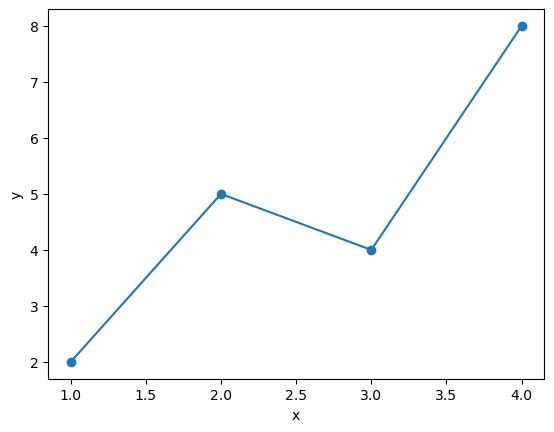

In [126]:


pairs = [(1, 2), (2, 5), (3, 4), (4, 8)]

x, y = zip(*pairs)

plt.plot(x, y, marker='o')

plt.xlabel("x")

plt.ylabel("y")

plt.show()

In [174]:
data = pd.read_csv("dataDropped_from_162by127_to_157rowsby84columns.csv", sep=";")
dfexp2 = data[data.columns[1:]]
dfexp2.index = range(4, 161)
dfexp2

,1,2,3,4,5,6,7,8,15,16,...,118,119,120,121,122,123,124,125,126,127
4,0.0,19.0,0.0,60.0,0.0,127.0,127.0,254.0,32258.0,127.0,...,41.5,37.5,39.1,26.82,41.06,67.88,134.08,0.506,67.88,1286.000
5,1.0,22.0,0.0,56.0,0.0,127.0,127.0,254.0,32258.0,127.0,...,100.2,96.2,97.8,41.32,41.06,82.39,206.62,0.399,82.39,1245.000
6,2.0,23.0,0.0,57.0,0.0,127.0,127.0,254.0,32258.0,127.0,...,91.8,87.8,89.4,39.51,53.38,92.89,197.53,0.470,92.89,1168.000
7,3.0,24.0,0.0,58.0,0.0,127.0,127.0,254.0,32258.0,127.0,...,105.3,101.3,102.9,42.38,64.05,106.44,211.92,0.502,106.44,1154.000
8,4.0,25.0,0.0,59.0,0.0,127.0,127.0,254.0,32258.0,127.0,...,100.8,96.8,98.4,41.45,41.06,82.51,207.26,0.398,82.51,1140.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
156,134.0,817.0,35.0,1.0,1.0,200.0,200.0,300.0,60000.0,150.0,...,47.9,43.9,45.5,58.26,49.37,107.63,291.28,0.369,107.63,1585.000
157,135.0,819.0,35.0,2.0,1.0,200.0,200.0,300.0,60000.0,150.0,...,50.4,46.4,48.0,59.82,159.73,219.55,299.09,0.734,219.55,0.867
158,31.0,820.0,16.0,25.0,1.0,655.0,155.0,820.0,207100.0,282.6,...,30.8,26.8,28.4,98.76,291.68,390.44,493.81,0.791,390.44,1683.000
159,32.0,821.0,16.0,27.0,1.0,655.0,155.0,820.0,207100.0,282.6,...,31.4,27.4,29.0,99.73,218.76,318.49,498.65,0.639,318.49,1794.000


In [176]:
dfexp2['Target'] = 1
#dfexp2['Target']

# Scree Plot

NameError: name 'StandardScaler' is not defined

NameError: name 'pca' is not defined